# NYPD Arrest Data Analysis
### Comparing Arrests in Brooklyn vs. Bronx

## 1. Importing the data set

In [3]:
# Importing the libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

# Importing the csv file into google colab
from google.colab import files
uploaded = files.upload()


Saving NYPD_Arrest_Data_(Year_to_Date)_20260402.csv to NYPD_Arrest_Data_(Year_to_Date)_20260402 (1).csv


In [ ]:
# Importing the Data Set

df=pd.read_csv("NYPD_Arrest_Data_(Year_to_Date)_20260402.csv")

## 2. Initial Exploration

In [6]:
# Number of columns and rows imported
print("Data Fields , # of Columns ", df.shape)
df.head()

# Column names and data types
print(df.dtypes)

# Check unique boroughs
print("\nBorough codes:", df['ARREST_BORO'].unique())

# Check age groups
print("\nAge groups:", df['AGE_GROUP'].unique())

Data Fields , # of Columns  (278953, 19)
ARREST_KEY             int64
ARREST_DATE           object
PD_CD                  int64
PD_DESC               object
KY_CD                float64
OFNS_DESC             object
LAW_CODE              object
LAW_CAT_CD            object
ARREST_BORO           object
ARREST_PRECINCT        int64
JURISDICTION_CODE      int64
AGE_GROUP             object
PERP_SEX              object
PERP_RACE             object
X_COORD_CD             int64
Y_COORD_CD             int64
Latitude             float64
Longitude            float64
Location              object
dtype: object

Borough codes: ['Q' 'S' 'B' 'K' 'M']

Age groups: ['25-44' '(null)' '45-64' '<18' '18-24' '65+']


Boroughs are coded to only one letter and age group has a group in blank, two good columns to work on during at data cleaning

## 3. Data Cleaning

In [11]:
# Function that creates a new column to enter the entire spelling of the borough
borough_map = {
    'B': 'Bronx',
    'S': 'Staten Island',
    'K': 'Brooklyn',
    'M': 'Manhattan',
    'Q': 'Queens'
}
df['BOROUGH_NAME'] = df['ARREST_BORO'].map(borough_map)

# Printing data by borough
print("Borough counts:")
print(df['BOROUGH_NAME'].value_counts())

df.shape #Verifying the creation of the new column

Borough counts:
BOROUGH_NAME
Brooklyn         79882
Manhattan        66448
Bronx            62833
Queens           58083
Staten Island    11707
Name: count, dtype: int64


(278953, 20)

In [13]:
# Removing rows with unknown or invalid age groups
valid_ages = ['<18', '18-24', '25-44', '45-64', '65+']
before = len(df)
df = df[df['AGE_GROUP'].isin(valid_ages)]
after = len(df)
print("Rows removed due to invalid age group: " + str(before - after))
print("Remaining rows: "+ str(after))

Rows removed due to invalid age group: 0
Remaining rows: 131716


Aproximately 147k cells were removed due to invalid sex group

In [14]:
#Converting ARREST_DATE to date format
df['ARREST_DATE'] = pd.to_datetime(df['ARREST_DATE'], errors='coerce')

# Verifying the dataset year
df['ARREST_YEAR'] = df['ARREST_DATE'].dt.year
print("Year in dataset:", sorted(df['ARREST_YEAR'].dropna().unique()))

Years in dataset: [np.int32(2025)]


All data is from 2025

## 4. Filter: Brooklyn vs. Queens

In [15]:
# Creating a new subset with just Brooklyn and Bronx
df_filtered = df[df['BOROUGH_NAME'].isin(['Brooklyn', 'Bronx'])].copy()

print("Record counts:")
print(df_filtered['BOROUGH_NAME'].value_counts())

Record counts:
BOROUGH_NAME
Brooklyn    35640
Bronx       24252
Name: count, dtype: int64


Arrest in Brooklyn are more than in the Bronx by approximately 9k.

## 5. Descriptive Statistics

In [26]:
# Total arrests per borough
print("Total arrests by borough:")
print(df_filtered['BOROUGH_NAME'].value_counts())

# Most common offense type per borough
print("\nTop 5 offenses in Brooklyn:")
print(df_filtered[df_filtered['BOROUGH_NAME'] == 'Brooklyn']['OFNS_DESC'].value_counts().head())

print("\nTop 5 offenses in Bronx:")
print(df_filtered[df_filtered['BOROUGH_NAME'] == 'Bronx']['OFNS_DESC'].value_counts().head())

# Breakdown by offense level (felony, misdemeanor, violation)
print("\nOffense level breakdown by borough:")
print(df_filtered.groupby(['BOROUGH_NAME', 'LAW_CAT_CD']).size().unstack(fill_value=0))

Total arrests by borough:
BOROUGH_NAME
Brooklyn    35640
Bronx       24252
Name: count, dtype: int64

Top 5 offenses in Brooklyn:
OFNS_DESC
ASSAULT 3 & RELATED OFFENSES    3875
FELONY ASSAULT                  3488
MISCELLANEOUS PENAL LAW         3325
PETIT LARCENY                   3083
DANGEROUS DRUGS                 2836
Name: count, dtype: int64

Top 5 offenses in Bronx:
OFNS_DESC
ASSAULT 3 & RELATED OFFENSES    3020
FELONY ASSAULT                  2676
PETIT LARCENY                   2195
DANGEROUS DRUGS                 2180
MISCELLANEOUS PENAL LAW         1705
Name: count, dtype: int64

Offense level breakdown by borough:
LAW_CAT_CD     9      F   I      M    V
BOROUGH_NAME                           
Bronx         37  12102  18  11682   44
Brooklyn      64  17652  29  16911  839


Top 2 offenses are the same in both borough, the other 3 top offenses are the same but not in the same order

## 6. Visualizations

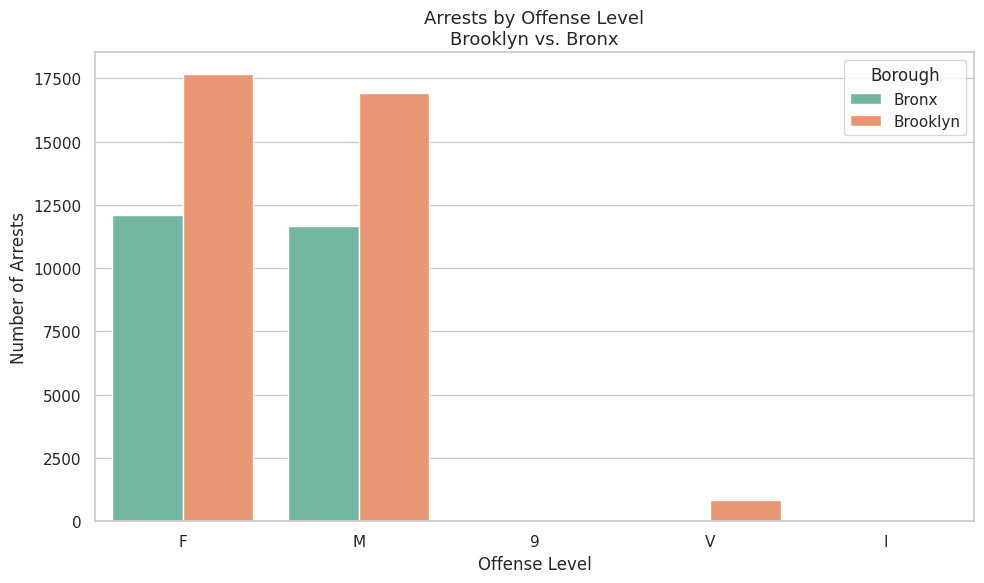

In [24]:
# Set Seaborn theme
sns.set_theme(style='whitegrid', palette='Set2')

# Arrests by offense level
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_filtered,
    x='LAW_CAT_CD',
    hue='BOROUGH_NAME',
    palette='Set2'
)
plt.title('Arrests by Offense Level\nBrooklyn vs. Bronx', fontsize=13)
plt.xlabel('Offense Level')
plt.ylabel('Number of Arrests')
plt.legend(title='Borough')
plt.tight_layout()
plt.savefig('countplot_offense_level.png', dpi=150)
plt.show()


Brooklyn has more number of arrest in total, maybe because has a bigger population.

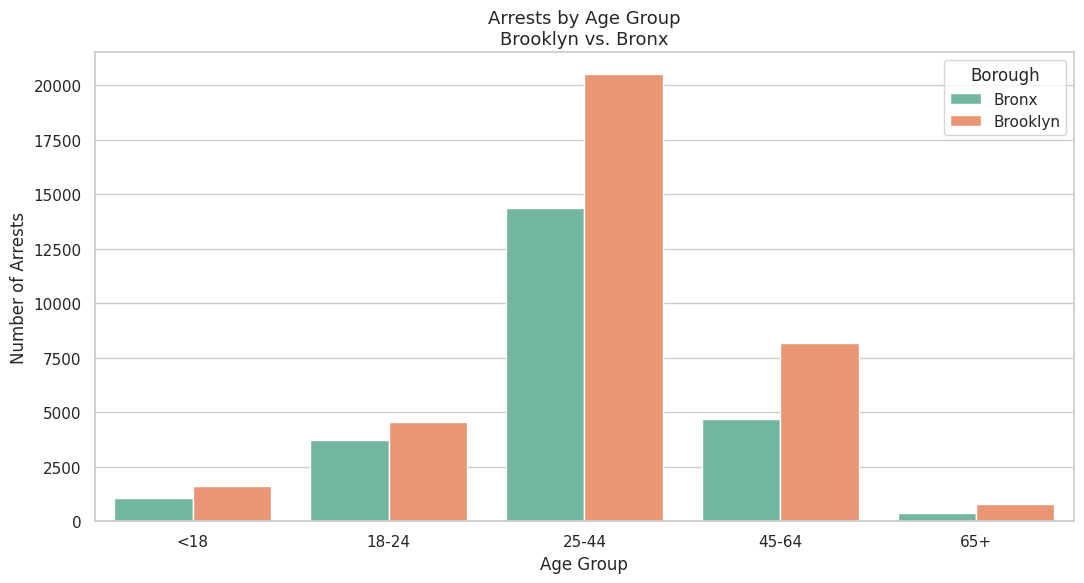

In [22]:
# Arrests by Age Group ---
plt.figure(figsize=(11, 6))
sns.countplot(
    data=df_filtered,
    x='AGE_GROUP',
    hue='BOROUGH_NAME',
    palette='Set2',
    order=['<18', '18-24', '25-44', '45-64', '65+']
)
plt.title('Arrests by Age Group\nBrooklyn vs. Bronx', fontsize=13)
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')
plt.legend(title='Borough')
plt.tight_layout()
plt.savefig('countplot_age_group.png', dpi=150)
plt.show()


In both boroughs, people between 25 and 44 years old has higher number of arrests

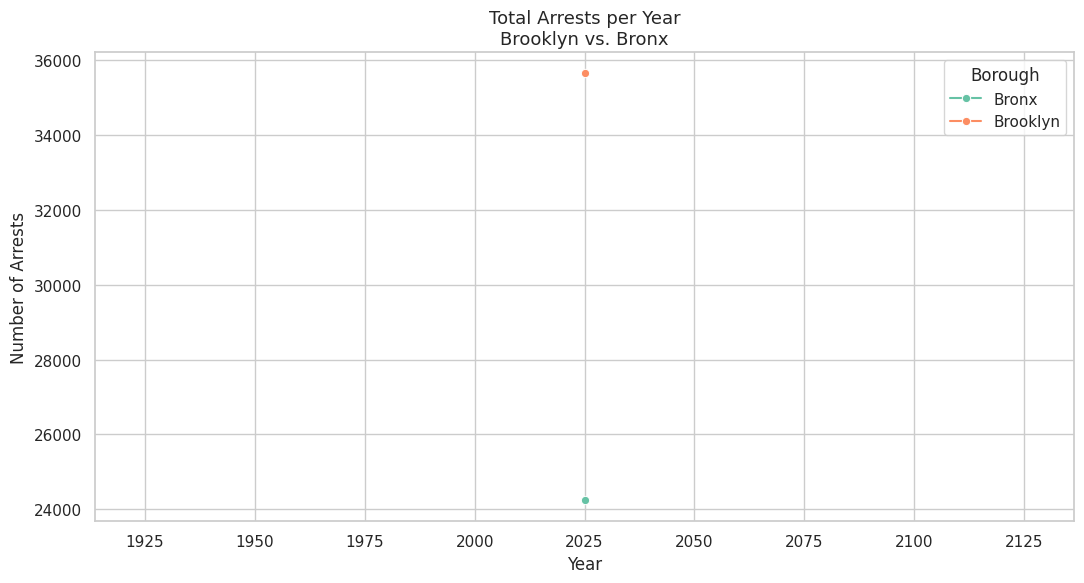

In [23]:
# Arrests per Year by Borough ---
arrests_by_year = (
    df_filtered.groupby(['ARREST_YEAR', 'BOROUGH_NAME'])
    .size()
    .reset_index(name='arrest_count')
)

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=arrests_by_year,
    x='ARREST_YEAR',
    y='arrest_count',
    hue='BOROUGH_NAME',
    marker='o',
    palette='Set2'
)
plt.title('Total Arrests per Year\nBrooklyn vs. Bronx', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Number of Arrests')
plt.legend(title='Borough')
plt.tight_layout()
plt.savefig('lineplot_arrests_by_year.png', dpi=150)
plt.show()


Only one year (2025) in the data set, as expected, only two dots are shown

## 7. Conclusion

After analyzing the NYPD arrest data, Brooklyn consistently shows a higher number of total arrests compared to the Bronx across all years, with the same 2 misdemeanors being the most common offense level in both boroughs. The 25 to 44 age group accounts for the largest share of arrests in both Brooklyn and Bronx, suggesting that young adults are the most frequently arrested demographic. It is also worth noting that according to the latest census, Brookly' population was at 2.6 million, while the Bronx has 1.4 millions. This demographoc disparity may significantly influence the final result.